In [1]:
# ==============================================================================
# STAGE 1: ENVIRONMENT SETUP & DEPENDENCIES
# Purpose: Import required libraries for data manipulation, machine learning pipelines,
#          evaluation metrics (vital for imbalanced data), and explainability.
# ==============================================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, average_precision_score
)

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib

In [2]:
#  uploading the IBM Telco dataset
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
# ==============================================================================
# STAGE 2: DATA ACQUISITION & CLEANING
# Purpose: Load the raw dataset and establish a clean baseline by removing
#          identifiers and handling missing or malformed data types.
# ==============================================================================
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("Shape:", df.shape)
df.head()

df = df.copy()

# Drop ID column as it holds no predictive value
if "customerID" in df.columns:
    df.drop(columns=["customerID"], inplace=True)

# Fix TotalCharges (convert strings with blanks to numeric NaN, then drop)
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Standardize the target variable format
df["Churn"] = df["Churn"].astype(str).str.strip()

# Drop rows with missing values to ensure model stability
df = df.dropna()

print("After cleaning shape:", df.shape)
print(df["Churn"].value_counts())

Shape: (7043, 21)
After cleaning shape: (7032, 20)
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [4]:
# ==============================================================================
# STAGE 3: DATA SPLITTING & STRATIFICATION
# Purpose: Separate features from the target and split the data while maintaining
#          the original proportion of churners (stratification).
# ==============================================================================
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})

print("Churn rate:", y.mean())
X.head()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Churn rate: 0.26578498293515357
Train churn rate: 0.2657777777777778
Test churn rate: 0.2658137882018479


In [5]:
# ==============================================================================
# STAGE 4: UNIFIED PREPROCESSING FRAMEWORK
# Purpose: Create a consistent pipeline for scaling and encoding that can be
#          applied identically to both interpretable and ensemble models.
# ==============================================================================
def build_preprocess(X_df):
    cat_cols = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", StandardScaler(), num_cols)
        ],
        remainder="drop"
    )
    return preprocess, cat_cols, num_cols

preprocess_raw, cat_cols_raw, num_cols_raw = build_preprocess(X_train)

print("Categorical:", cat_cols_raw)
print("Numeric:", num_cols_raw)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [6]:
# ==============================================================================
# STAGE 5: EVALUATION STRATEGY
# Purpose: Define a comprehensive evaluation function prioritizing metrics like
#          PR-AUC and Recall, which are critical for imbalanced telecom data.
# ==============================================================================
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    # Safely extract probabilities for AUC calculations
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    metrics = {}
    metrics["Model"] = model_name
    metrics["Precision"] = precision_score(y_test, y_pred, zero_division=0)
    metrics["Recall"] = recall_score(y_test, y_pred, zero_division=0)
    metrics["F1"] = f1_score(y_test, y_pred, zero_division=0)

    if y_proba is not None:
        metrics["ROC_AUC"] = roc_auc_score(y_test, y_proba)
        metrics["PR_AUC"] = average_precision_score(y_test, y_proba)
    else:
        metrics["ROC_AUC"] = np.nan
        metrics["PR_AUC"] = np.nan

    cm = confusion_matrix(y_test, y_pred)
    return metrics, cm, y_pred, y_proba

In [7]:
# ==============================================================================
# STAGE 6: BASELINE MODEL BENCHMARKING (RAW FEATURES)
# Purpose: Train and compare interpretable models (LogReg, Decision Tree) against
#          complex ensembles (Random Forest, Gradient Boosting) on raw data.
# ==============================================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

raw_results = []
raw_conf_matrices = {}
trained_models_raw = {}

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess_raw),
        ("clf", clf)
    ])
    pipe.fit(X_train, y_train)

    metrics, cm, y_pred, y_proba = evaluate_model(pipe, X_test, y_test, model_name=name)
    raw_results.append(metrics)
    raw_conf_matrices[name] = cm
    trained_models_raw[name] = pipe

raw_results_df = pd.DataFrame(raw_results).sort_values(by="F1", ascending=False)
raw_results_df



,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.648485,0.572193,0.607955,0.835929,0.622817
3,Gradient Boosting,0.638710,0.529412,0.578947,0.838327,0.650957
2,Random Forest,0.615646,0.483957,0.541916,0.812160,0.593250
1,Decision Tree,0.476804,0.494652,0.485564,0.649308,0.370790


Best RAW model: Logistic Regression
Confusion matrix:
 [[917 116]
 [160 214]]


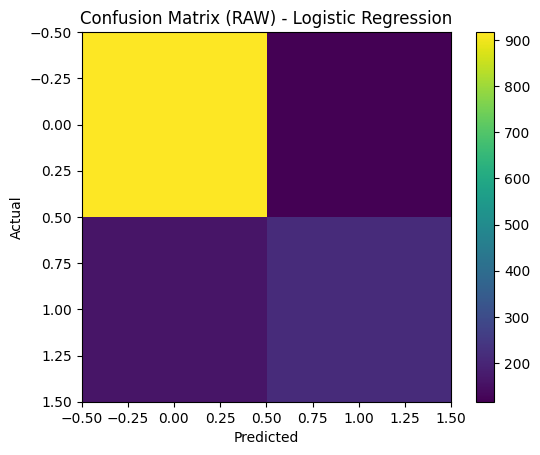

In [8]:
# Identify and visualize the best raw model's confusion matrix
best_raw_model_name = raw_results_df.iloc[0]["Model"]
print("Best RAW model:", best_raw_model_name)

cm = raw_conf_matrices[best_raw_model_name]
print("Confusion matrix:\n", cm)

plt.figure()
plt.imshow(cm)
plt.title(f"Confusion Matrix (RAW) - {best_raw_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [9]:
# ==============================================================================
# STAGE 7: FEATURE ENGINEERING & INNOVATION LAYER
# Purpose: Integrate domain knowledge to create new predictive signals (tenure
#          bands, contract risk, service bundles) to test against raw performance.
# ==============================================================================
def feature_engineer(df_in):
    df_fe = df_in.copy()

    # Tenure segmentation
    if "tenure" in df_fe.columns:
        df_fe["tenure_band"] = pd.cut(
            df_fe["tenure"],
            bins=[-1, 6, 12, 24, 1000],
            labels=["0-6", "6-12", "12-24", "24+"]
        )

    # Contract risk flag (identifying high-risk month-to-month contracts)
    if "Contract" in df_fe.columns:
        df_fe["is_month_to_month"] = (df_fe["Contract"].astype(str).str.lower() == "month-to-month").astype(int)

    # Service bundle count (aggregate of subscribed services)
    service_cols = [
        "PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
        "DeviceProtection","TechSupport","StreamingTV","StreamingMovies"
    ]
    existing_service_cols = [c for c in service_cols if c in df_fe.columns]

    if existing_service_cols:
        def yes_count(row):
            return sum(str(row[c]).strip().lower() == "yes" for c in existing_service_cols)
        df_fe["service_count"] = df_fe.apply(yes_count, axis=1)
    #  Charge-to-tenure ratio (avoid divide by zero)
    if "MonthlyCharges" in df_fe.columns and "tenure" in df_fe.columns:
        df_fe["charge_to_tenure"] = df_fe["MonthlyCharges"] / (df_fe["tenure"] + 1)

    return df_fe

# Apply feature engineering and recreate stratified splits
X_fe = feature_engineer(X)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocess_fe, cat_cols_fe, num_cols_fe = build_preprocess(X_train_fe)
print("Engineered categorical:", cat_cols_fe)
print("Engineered numeric:", num_cols_fe)


Engineered categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_band']
Engineered numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'is_month_to_month', 'service_count', 'charge_to_tenure']


In [10]:
# ==============================================================================
# STAGE 8: ABLATION STUDY (ENGINEERED FEATURES BENCHMARKING)
# Purpose: Retrain all models on the newly engineered features to evaluate the
#          impact of the custom variables on overall predictive power.
# ==============================================================================
fe_results = []
fe_conf_matrices = {}
trained_models_fe = {}

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess_fe),
        ("clf", clf)
    ])
    pipe.fit(X_train_fe, y_train_fe)

    metrics, cm, y_pred, y_proba = evaluate_model(pipe, X_test_fe, y_test_fe, model_name=name)
    fe_results.append(metrics)
    fe_conf_matrices[name] = cm
    trained_models_fe[name] = pipe

fe_results_df = pd.DataFrame(fe_results).sort_values(by="F1", ascending=False)
fe_results_df



,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
3,Gradient Boosting,0.636646,0.548128,0.589080,0.838433,0.655704
0,Logistic Regression,0.640127,0.537433,0.584302,0.837733,0.655634
2,Random Forest,0.614094,0.489305,0.544643,0.815327,0.597902
1,Decision Tree,0.485366,0.532086,0.507653,0.663687,0.382634


In [11]:
# Compare Raw vs. Engineered feature performance
raw_tbl = raw_results_df.set_index("Model")[["Precision","Recall","F1","ROC_AUC","PR_AUC"]].copy()
fe_tbl  = fe_results_df.set_index("Model")[["Precision","Recall","F1","ROC_AUC","PR_AUC"]].copy()

comparison = raw_tbl.join(fe_tbl, lsuffix="_RAW", rsuffix="_FE")
comparison["F1_Improvement"] = comparison["F1_FE"] - comparison["F1_RAW"]
comparison = comparison.sort_values("F1_Improvement", ascending=False)
comparison


,Precision_RAW,Recall_RAW,F1_RAW,ROC_AUC_RAW,PR_AUC_RAW,Precision_FE,Recall_FE,F1_FE,ROC_AUC_FE,PR_AUC_FE,F1_Improvement
Model,,,,,,,,,,,
Decision Tree,0.476804,0.494652,0.485564,0.649308,0.370790,0.485366,0.532086,0.507653,0.663687,0.382634,0.022089
Gradient Boosting,0.638710,0.529412,0.578947,0.838327,0.650957,0.636646,0.548128,0.589080,0.838433,0.655704,0.010133
Random Forest,0.615646,0.483957,0.541916,0.812160,0.593250,0.614094,0.489305,0.544643,0.815327,0.597902,0.002727
Logistic Regression,0.648485,0.572193,0.607955,0.835929,0.622817,0.640127,0.537433,0.584302,0.837733,0.655634,-0.023652


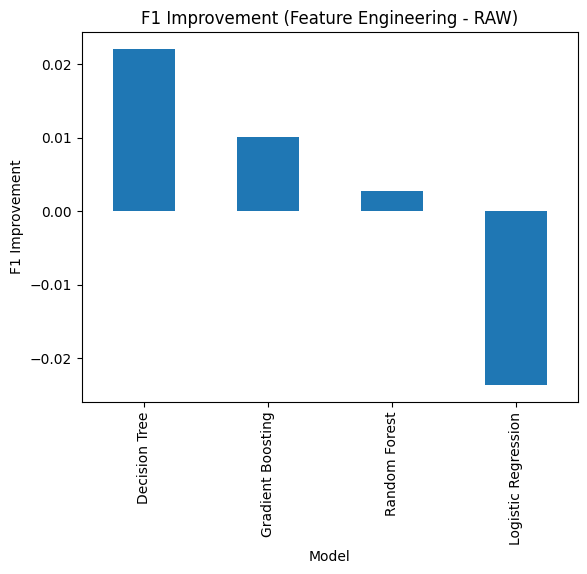

In [12]:
plt.figure()
comparison["F1_Improvement"].plot(kind="bar")
plt.title("F1 Improvement (Feature Engineering - RAW)")
plt.xlabel("Model")
plt.ylabel("F1 Improvement")
plt.show()

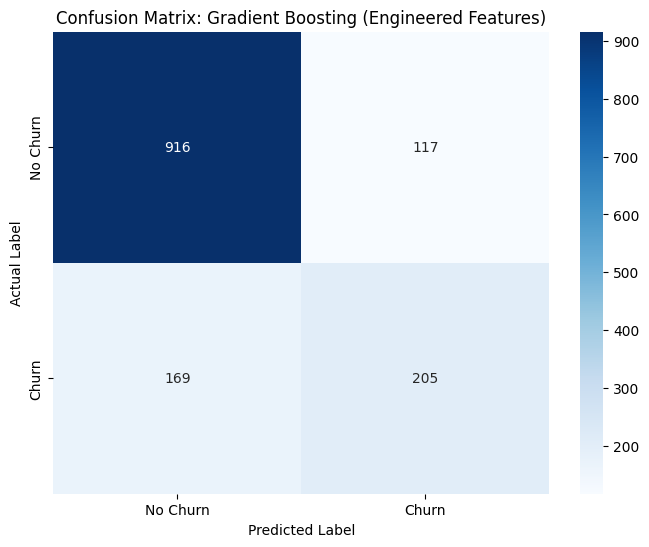

True Negatives: 916
False Positives: 117
False Negatives: 169
True Positives: 205


In [14]:
#Confusion Matrix (Engineered Feature)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Retrieve the confusion matrix for Gradient Boosting from your stored results
gb_cm_fe = fe_conf_matrices["Gradient Boosting"]

# 2. Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(gb_cm_fe, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.title('Confusion Matrix: Gradient Boosting (Engineered Features)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. Print the raw values for your report
tn, fp, fn, tp = gb_cm_fe.ravel()
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

Best ENGINEERED model: Gradient Boosting


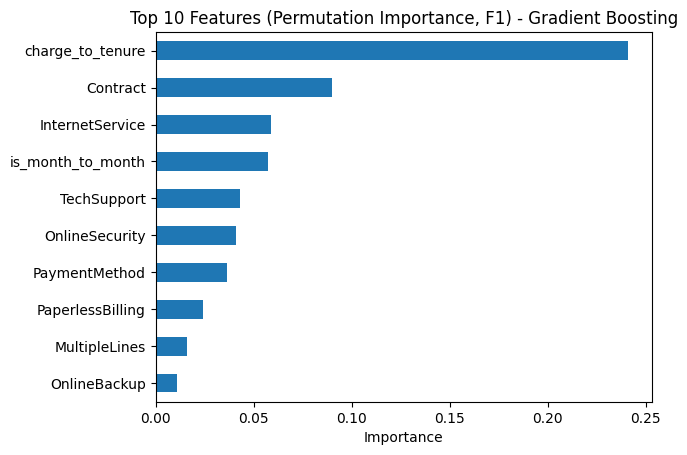

In [15]:
# ==============================================================================
# STAGE 9: PERMUTATION IMPORTANCE ANALYSIS
# Purpose: Identify the top driving features of the best-performing ensemble
#          model before applying SHAP for deeper transparency.
# ==============================================================================
best_fe_model_name = fe_results_df.iloc[0]["Model"]
best_fe_model = trained_models_fe[best_fe_model_name]

print("Best ENGINEERED model:", best_fe_model_name)

perm = permutation_importance(
    best_fe_model, X_test_fe, y_test_fe,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)
# Get feature names that permutation_importance actually used (the input features)
feature_names_for_importance = X_test_fe.columns
importances = pd.Series(perm.importances_mean, index=feature_names_for_importance).sort_values(ascending=False)

top10 = importances.head(10).sort_values()
plt.figure()
top10.plot(kind="barh")
plt.title(f"Top 10 Features (Permutation Importance, F1) - {best_fe_model_name}")
plt.xlabel("Importance")
plt.show()

In [ ]:
# ==============================================================================
# STAGE 10: EXPORTING RESULTS AND MODELS
# Purpose: Save benchmark results and serialize the best pipeline for future
#          deployment or offline analysis.
# ==============================================================================
raw_results_df.to_csv("results_raw.csv", index=False)
fe_results_df.to_csv("results_engineered.csv", index=False)
comparison.to_csv("ablation_comparison.csv", index=True)
joblib.dump(best_fe_model, "best_churn_model.joblib")

files.download("results_raw.csv")
files.download("results_engineered.csv")
files.download("ablation_comparison.csv")
files.download("best_churn_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

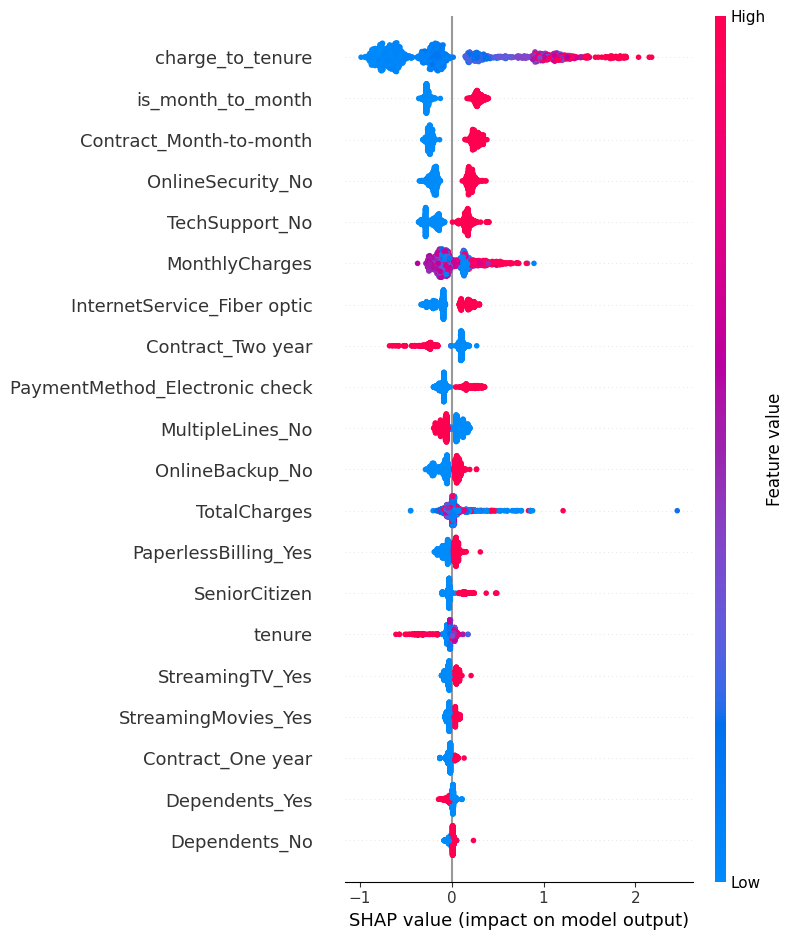

In [16]:
# ==============================================================================
# STAGE 11: EXPLAINABLE AI (XAI) LAYER WITH SHAP
# Purpose: Demystify the "black-box" ensemble model by providing both global
#          (overall drivers) and local (individual customer) explanations.
# ==============================================================================
!pip install shap
import shap

# Extract the preprocessing steps and the trained classifier from the pipeline
preprocess = best_fe_model.named_steps["preprocess"]
model = best_fe_model.named_steps["clf"]

# Transform test data specifically for SHAP analysis
X_test_transformed = preprocess.transform(X_test_fe)

# Map original feature names to the transformed array
ohe = preprocess.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols_fe)
all_feature_names = list(cat_feature_names) + num_cols_fe

# Initialize TreeExplainer (optimized for tree-based ensemble models)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# Handle output structures for binary classification tasks
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Generate Global Explanation (Feature importance and directionality)
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names
)





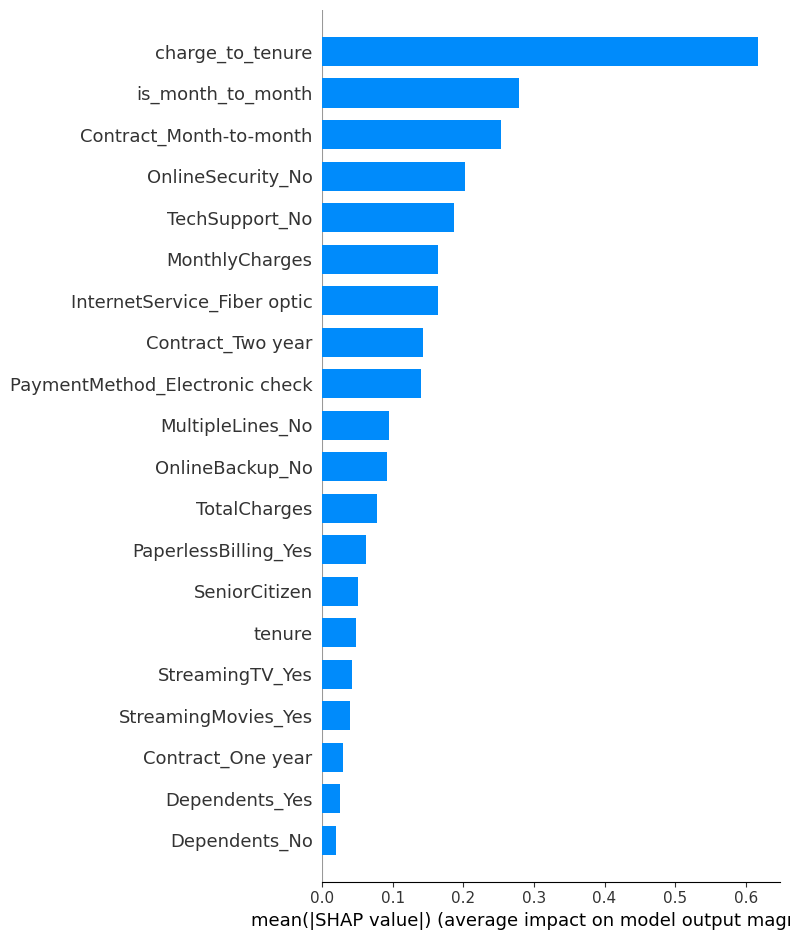

In [17]:
# Generate Global Explanation (Standard bar chart representation)
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    plot_type="bar"
)

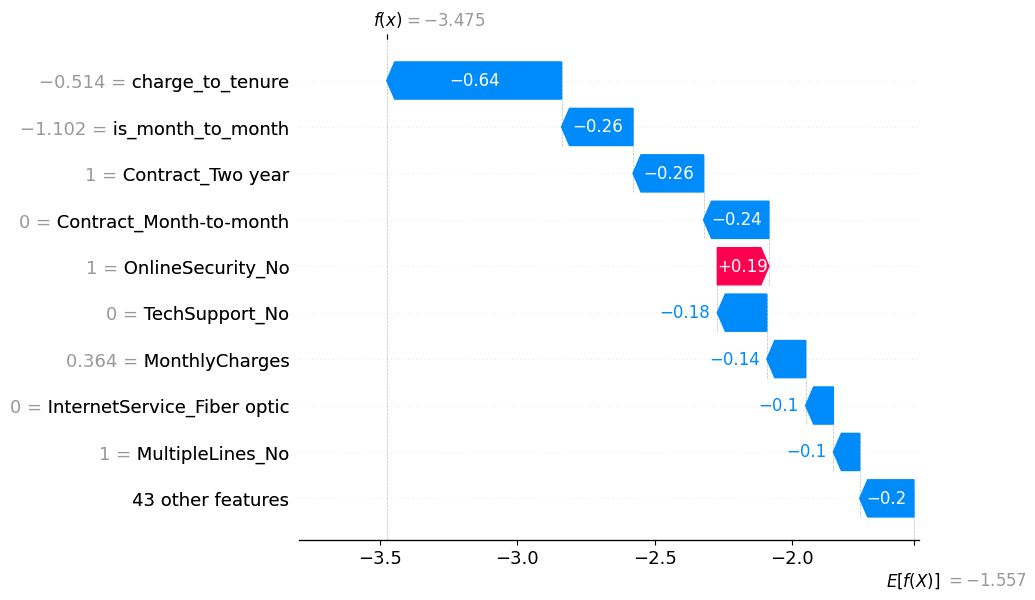

In [18]:
# Generate Local Explanation (Understanding a specific customer's churn risk)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_transformed[0],
        feature_names=all_feature_names
    )
)